<a href="https://colab.research.google.com/github/KishoreKumar477/ml-supervised/blob/main/model_comp_dt_vs_randomforets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Decision Tree Classifier Example

This example demonstrates how to train a Decision Tree Classifier using the Iris dataset, which is a classic dataset for multi-class classification. We will cover data loading, splitting, model training, prediction, evaluation, and even visualization of the decision tree itself.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Feature names:", feature_names)
print("Target names:", target_names)

# Display first 5 rows of the data
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['species'] = np.array([target_names[i] for i in y])
display(df_iris.head())

Features (X) shape: (150, 4)
Target (y) shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Now that the dataset is loaded, we'll split it into training and testing sets. This allows us to train the model on one part of the data and evaluate its performance on unseen data.

In [ ]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training data samples: {X_train.shape[0]}")
print(f"Testing data samples: {X_test.shape[0]}")
print(f"Training target distribution: {np.bincount(y_train)}")
print(f"Testing target distribution: {np.bincount(y_test)}")

Training data samples: 105
Testing data samples: 45
Training target distribution: [35 35 35]
Testing target distribution: [15 15 15]


Next, we will initialize a `DecisionTreeClassifier` and train it using our training data. We'll set a `max_depth` to prevent overfitting and make the tree easier to visualize.

In [ ]:
# 3. Create and train the Decision Tree Classifier
# Using max_depth to prevent overfitting and make the tree easier to visualize
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


After training, we can use the model to make predictions on the test set and then evaluate how well it performed using various metrics like accuracy, precision, recall, and F1-score. A confusion matrix will also help us see how many samples of each class were correctly classified.

Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



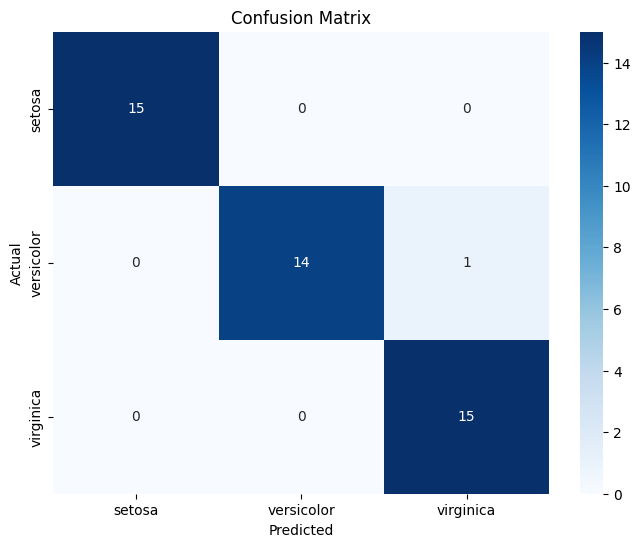

In [ ]:
# 4. Make predictions and evaluate the model
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Finally, a great feature of decision trees is their interpretability. We can visualize the entire tree structure, which shows how the model makes decisions based on the features.

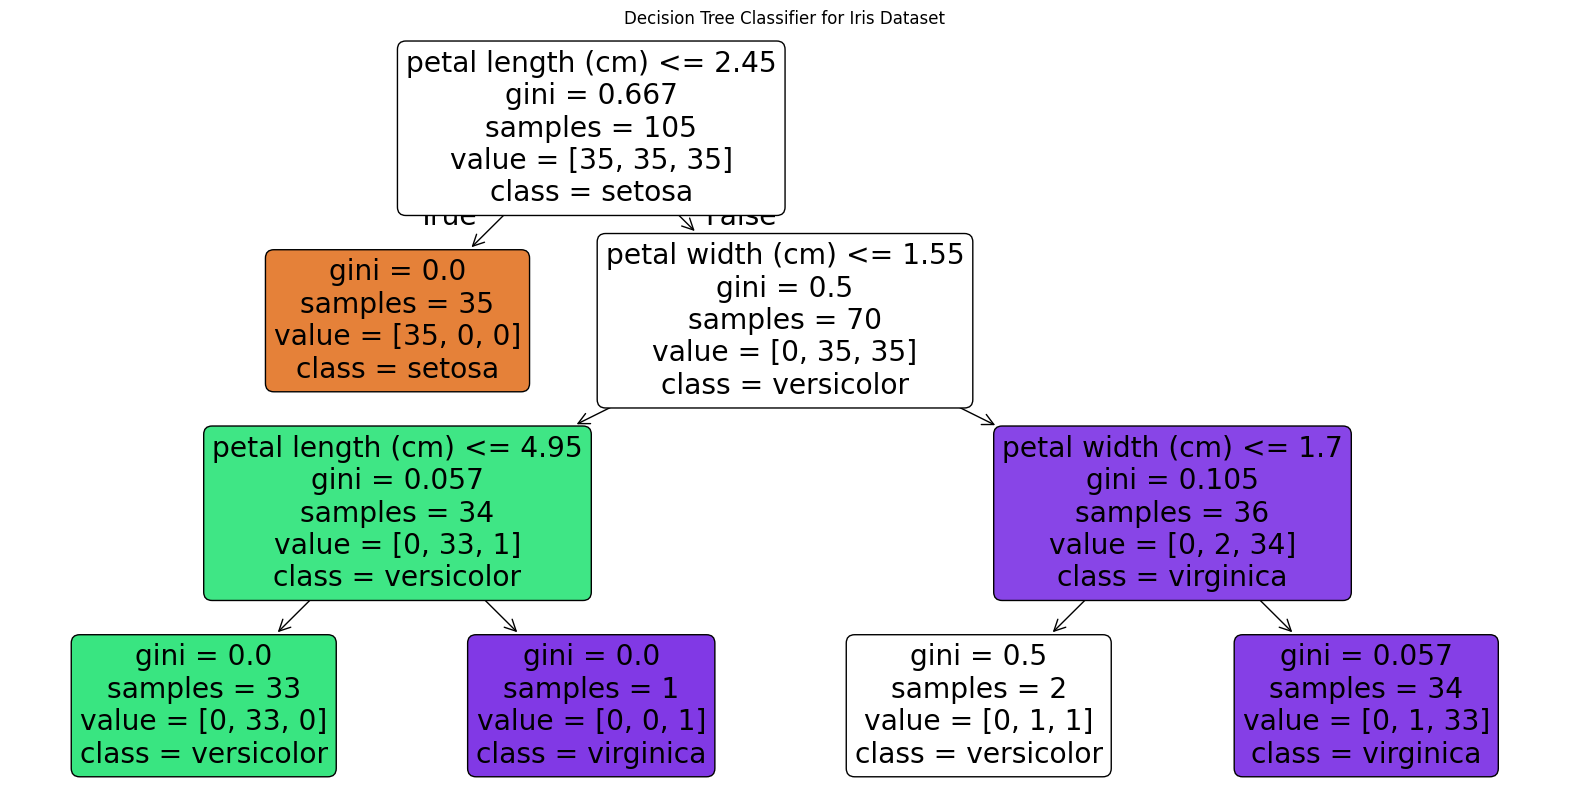

In [ ]:
# 5. Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True, feature_names=feature_names, class_names=target_names, rounded=True)
plt.title('Decision Tree Classifier for Iris Dataset')
plt.show()

# Task
Perform an exploratory data analysis (EDA) on the `california_housing_train.csv` dataset. The EDA should include displaying the first few rows, checking data types, summarizing basic statistics, identifying and visualizing missing values, analyzing numerical feature distributions, and computing/visualizing the correlation matrix for numerical features. Finally, summarize the key insights obtained from this analysis.

## Load a new dataset

### Subtask:
Load the `california_housing_train.csv` dataset into a pandas DataFrame.


**Reasoning**:
The subtask is to load the `california_housing_train.csv` dataset into a pandas DataFrame. I will use `pd.read_csv` to load the file and then display the head of the DataFrame to confirm it's loaded correctly.



In [ ]:
import pandas as pd

# Load the california_housing_train.csv dataset
df_housing = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the California Housing dataset:")
display(df_housing.head())

First 5 rows of the California Housing dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


## Initial Data Inspection

### Subtask:
Check data types and get a summary of basic statistics for the `df_housing` dataset.


**Reasoning**:
I will display the DataFrame's information including data types and non-null values using `.info()`, and then generate descriptive statistics for numerical columns using `.describe()` to satisfy the subtask instructions.



In [ ]:
print("\nDataFrame Info:")
df_housing.info()

print("\nDescriptive Statistics:")
display(df_housing.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB

Descriptive Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Check for Missing Values

### Subtask:
Identify and visualize any missing values in the dataset to understand data completeness.


**Reasoning**:
I will calculate and print the count of missing values for each column and then generate a heatmap to visually represent these missing values in the `df_housing` DataFrame.




Missing values per column:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


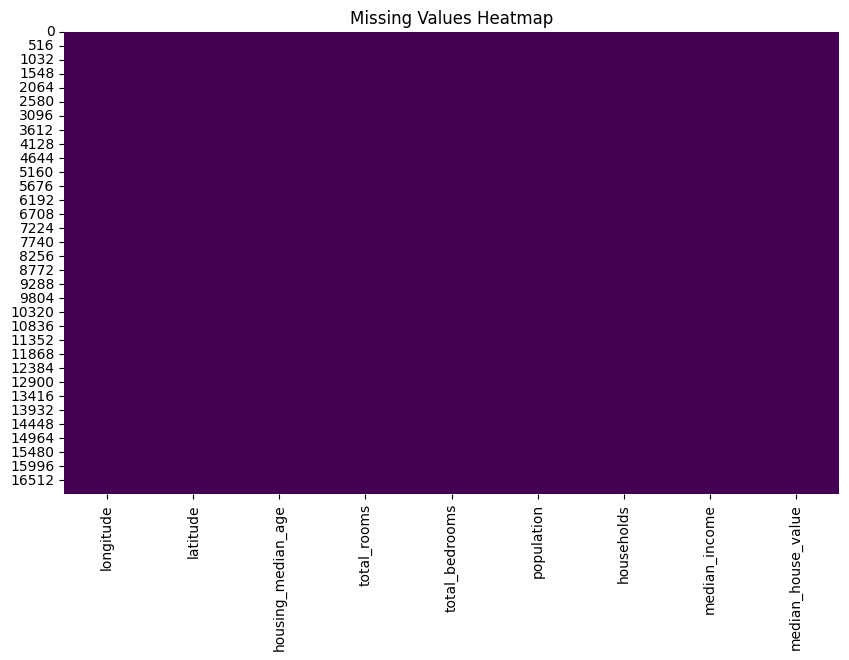

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate missing values for each column
missing_values = df_housing.isnull().sum()

# 2. Print the results
print("\nMissing values per column:")
print(missing_values)

# 3. Create a heatmap to visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df_housing.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## Analyze Numerical Feature Distributions

### Subtask:
Analyze the distributions of numerical features in the `df_housing` dataset. This involves creating histograms for each numerical column to visualize their spread, skewness, and potential outliers.

## Analyze Numerical Feature Distributions

### Subtask:
Analyze the distributions of numerical features in the `df_housing` dataset. This involves creating histograms for each numerical column to visualize their spread, skewness, and potential outliers.

## Analyze Numerical Feature Distributions

### Subtask:
Analyze the distributions of numerical features in the `df_housing` dataset. This involves creating histograms for each numerical column to visualize their spread, skewness, and potential outliers.

**Reasoning**:
To analyze the distribution of numerical features, I will generate histograms for each numerical column in the `df_housing` DataFrame. This will allow us to observe their spread, identify skewness, and detect potential outliers, fulfilling the current subtask.



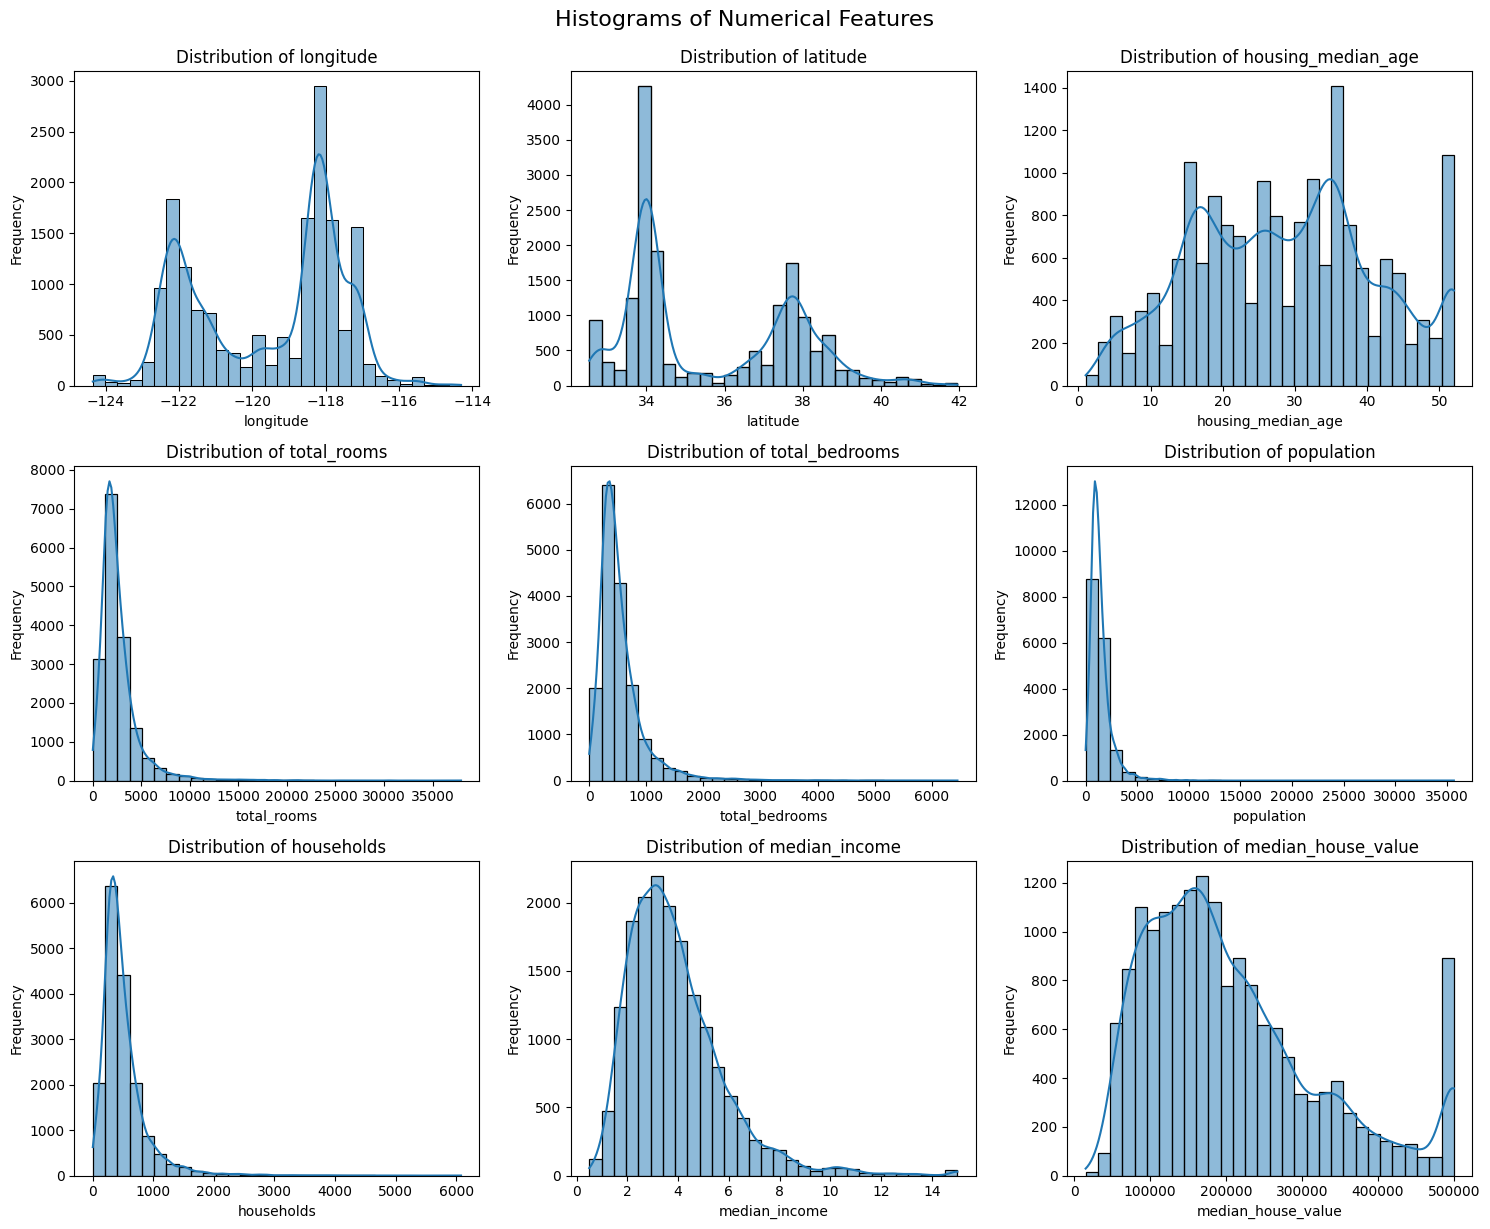

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for plotting histograms
numerical_cols = df_housing.select_dtypes(include=['float64', 'int64']).columns

# Determine the number of rows and columns for the subplot grid
n_cols = 3  # Adjust as needed
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_housing[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()

plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.show()

## Analyze Categorical Feature

---

Distributions

### Subtask:
Analyze the distributions of categorical features in the `df_housing` dataset. If no categorical features are present, state that.


## Analyze Categorical Feature Distributions

### Subtask:
Analyze the distributions of categorical features in the `df_housing` dataset. If no categorical features are present, state that.

#### Instructions
1. Review the data types of the `df_housing` DataFrame.
2. Based on the previous `df_housing.info()` output, all columns are numerical (`float64`). Therefore, there are no categorical features to analyze in this dataset.
3. No further action is required for this subtask as there are no categorical features to visualize.

## Correlation Analysis

### Subtask:
Compute and visualize the correlation matrix for numerical features to identify relationships between variables.


## Correlation Analysis

### Subtask:
Compute and visualize the correlation matrix for numerical features to identify relationships between variables.

**Reasoning**:
To understand the relationships between numerical features, I will calculate the correlation matrix for `df_housing`. A heatmap visualization will then be used to display these correlations, allowing for easy identification of strong positive, negative, or weak relationships between variables. This will help in understanding which features might move together or in opposite directions.

**Reasoning**:
Now that the reasoning for correlation analysis is explained, I will generate the code to calculate the correlation matrix for the numerical features in `df_housing` and then visualize it using a seaborn heatmap with annotations and a suitable colormap.



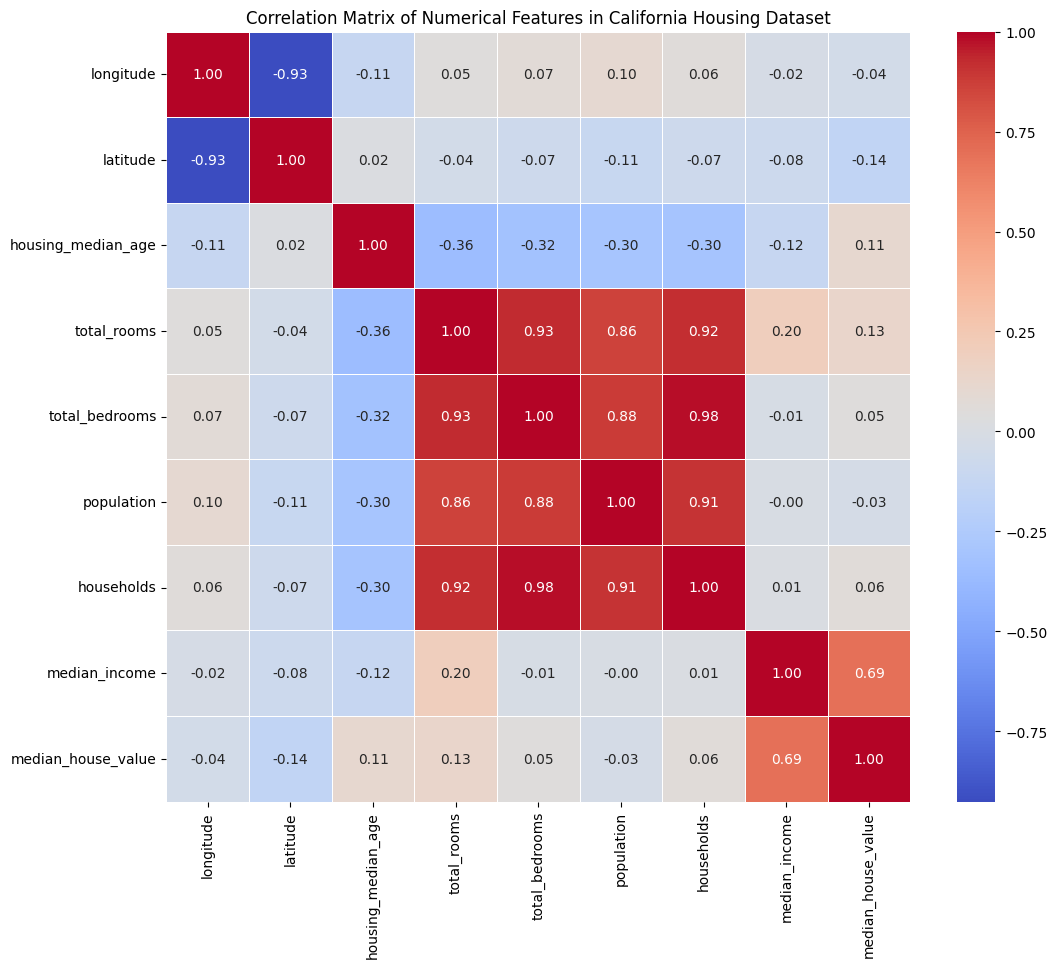

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix for numerical features
correlation_matrix = df_housing.corr()

# 2. Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features in California Housing Dataset')

# 4. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the key insights gained from the exploratory data analysis of the new dataset.


## Summary:

### Q&A
The key insights gained from the exploratory data analysis of the new dataset are summarized in the "Data Analysis Key Findings" section below.

### Data Analysis Key Findings
*   The `california_housing_train.csv` dataset contains 17,000 entries and 9 columns, all of which are of `float64` data type.
*   All columns have 17,000 non-null values, indicating that there are no missing values in the dataset.
*   Descriptive statistics show significant variability across numerical features:
    *   `housing_median_age` ranges from 1 to 52 years, with a mean of approximately 28.6 years.
    *   `total_rooms` and `total_bedrooms` have wide ranges, suggesting diverse housing sizes.
    *   `population` varies from 3 to 35,682, with a mean around 1429.
    *   `median_income` ranges from 0.4999 to 15.0001, averaging about 3.88.
    *   `median_house_value` ranges from \$14,999 to \$500,001, with a mean of approximately \$207,300.
*   The dataset does not contain any categorical features; all variables are numerical.
*   Correlation analysis revealed strong relationships between several features:
    *   `median_income` shows a strong positive correlation with `median_house_value`.
    *   `total_rooms`, `total_bedrooms`, `population`, and `households` are highly positively correlated with each other, suggesting they describe the size or density of a housing area.
    *   `longitude` and `latitude` show moderate correlations with other features, indicating geographical influence on housing characteristics and value.

### Insights or Next Steps
*   The strong positive correlation between `median_income` and `median_house_value` suggests `median_income` will be a crucial feature for predicting housing prices, and further investigation into this relationship could yield valuable predictive models.
*   Given the significant variance in features like `total_rooms`, `total_bedrooms`, `population`, and `median_house_value`, consider feature scaling or transformation techniques if building machine learning models to prevent features with larger ranges from dominating the learning process.


# Task
Prepare data for modeling: Separate the features (X) and the target variable (y), which is 'median_house_value', from the `df_housing` DataFrame. Then, split the data into training and testing sets.

## Prepare Data for Modeling

### Subtask:
Separate the features (X) and the target variable (y), which is 'median_house_value', from the `df_housing` DataFrame. Then, split the data into training and testing sets.


**Reasoning**:
I will separate the features (X) and the target variable (y) from the `df_housing` DataFrame, then split the data into training and testing sets, and finally print the shapes of the resulting sets to verify the split.



In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target variable (y)
X = df_housing.drop('median_house_value', axis=1)
y = df_housing['median_house_value']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Print the shapes of the resulting training and testing sets
print("\nShapes after splitting:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Shape of features (X): (17000, 8)
Shape of target (y): (17000,)

Shapes after splitting:
X_train shape: (13600, 8)
X_test shape: (3400, 8)
y_train shape: (13600,)
y_test shape: (3400,)


## Train Decision Tree Regressor

### Subtask:
Initialize and train a `DecisionTreeRegressor` model on the training data. We'll set a `random_state` for reproducibility and consider setting a `max_depth` to prevent overfitting.


### Reason
I will import the `DecisionTreeRegressor` from `sklearn.tree`, initialize it with `random_state=42` and `max_depth=10` (a common starting point to prevent overfitting), and then train the model using the `fit` method on the `X_train` and `y_train` datasets. Printing a confirmation message will verify that the model has been trained.

**Reasoning**:
To initialize and train the `DecisionTreeRegressor` model, I will import the necessary class, instantiate it with specified parameters like `random_state` and `max_depth`, and then fit the model to the training data (`X_train`, `y_train`).



In [ ]:
from sklearn.tree import DecisionTreeRegressor

# 1. Instantiate a DecisionTreeRegressor model
# Set random_state for reproducibility and max_depth to prevent overfitting
dtr_model = DecisionTreeRegressor(random_state=42, max_depth=10)

# 2. Train the model using the fit() method
dtr_model.fit(X_train, y_train)

print("DecisionTreeRegressor model trained successfully!")

DecisionTreeRegressor model trained successfully!


## Make Predictions and Evaluate Model

### Subtask:
Use the trained Decision Tree Regressor to make predictions on the test set. Evaluate the model's performance using appropriate regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared.


### Reasoning:
To evaluate the `DecisionTreeRegressor` model, I will use the `predict` method on the `X_test` data to generate predictions. Then, I will compute the Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared score by comparing these predictions (`y_pred`) against the actual target values (`y_test`). Finally, I will print all these metrics to present a comprehensive evaluation of the model's performance on unseen data.

**Reasoning**:
I will import the necessary regression metrics, make predictions on the test set using the trained `dtr_model`, calculate MAE, MSE, RMSE, and R-squared, and then print these metrics to evaluate the model's performance.



In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Make predictions on the test set
y_pred = dtr_model.predict(X_test)

# 2. Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 3. Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 41401.38
Mean Squared Error (MSE): 3950222628.51
Root Mean Squared Error (RMSE): 62850.80
R-squared (R2): 0.71


## Visualize Predictions

### Subtask:
Create a scatter plot comparing the actual median house values from the test set against the predicted median house values to visually assess the model's performance. Also, plot the residuals.


**Reasoning**:
To visualize the model's performance, I will generate two plots: a scatter plot comparing actual versus predicted median house values, including a perfect prediction line, and a residuals plot showing the difference between actual and predicted values against predicted values, with a zero error line. This will fulfill all the instructions for the subtask.



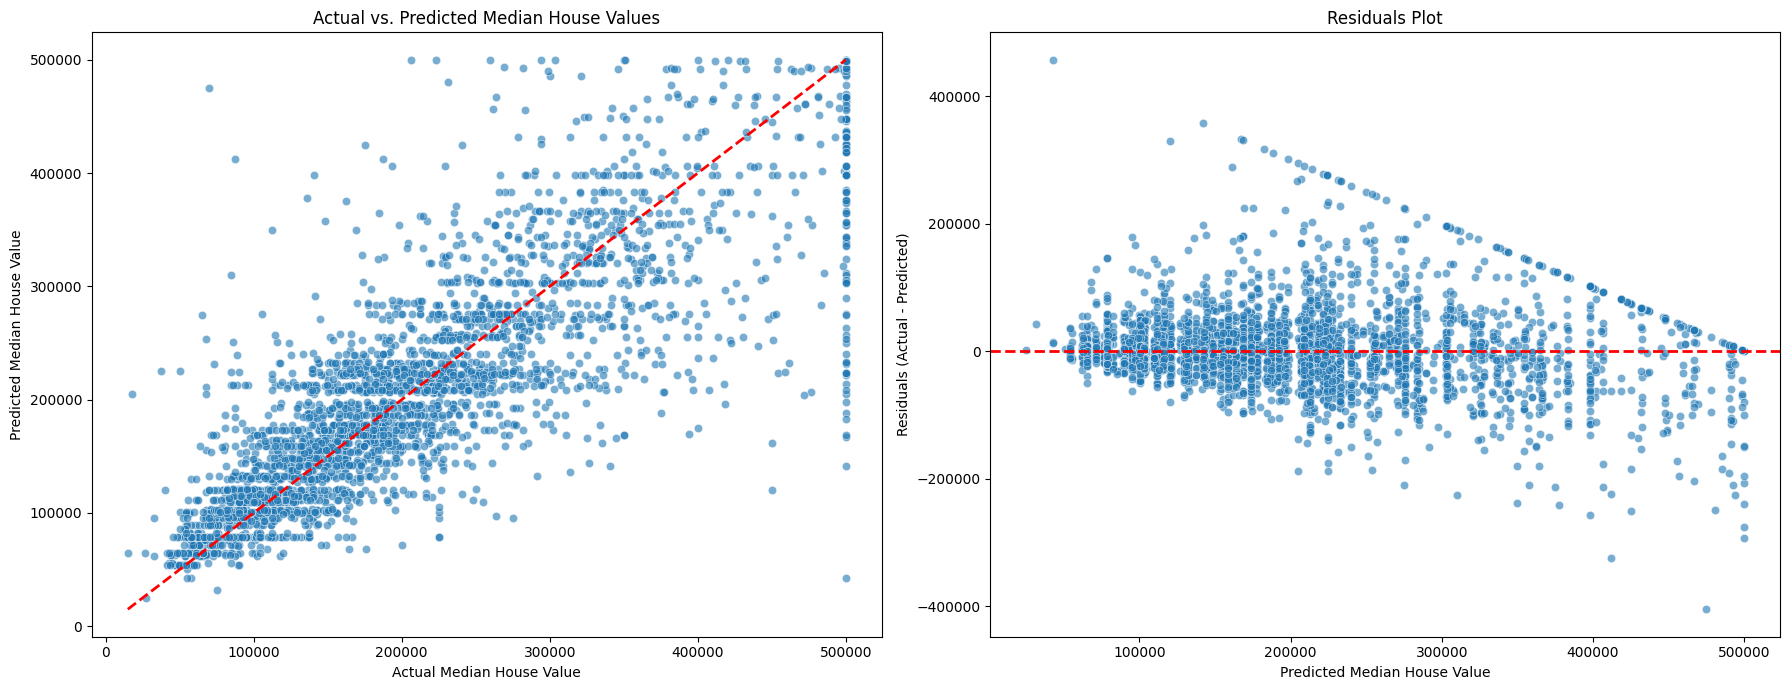

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Actual vs. Predicted Values
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Median House Value')
axes[0].set_ylabel('Predicted Median House Value')
axes[0].set_title('Actual vs. Predicted Median House Values')

# Plot 2: Residuals Plot
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.6)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Median House Value')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

## Visualize the Decision Tree

### Subtask:
Visualize the trained Decision Tree Regressor to understand the decision-making process. This will involve plotting the tree structure with feature names.


**Reasoning**:
To visualize the Decision Tree Regressor, I will use `sklearn.tree.plot_tree` with the trained model, appropriate figure size, feature names, and a title.



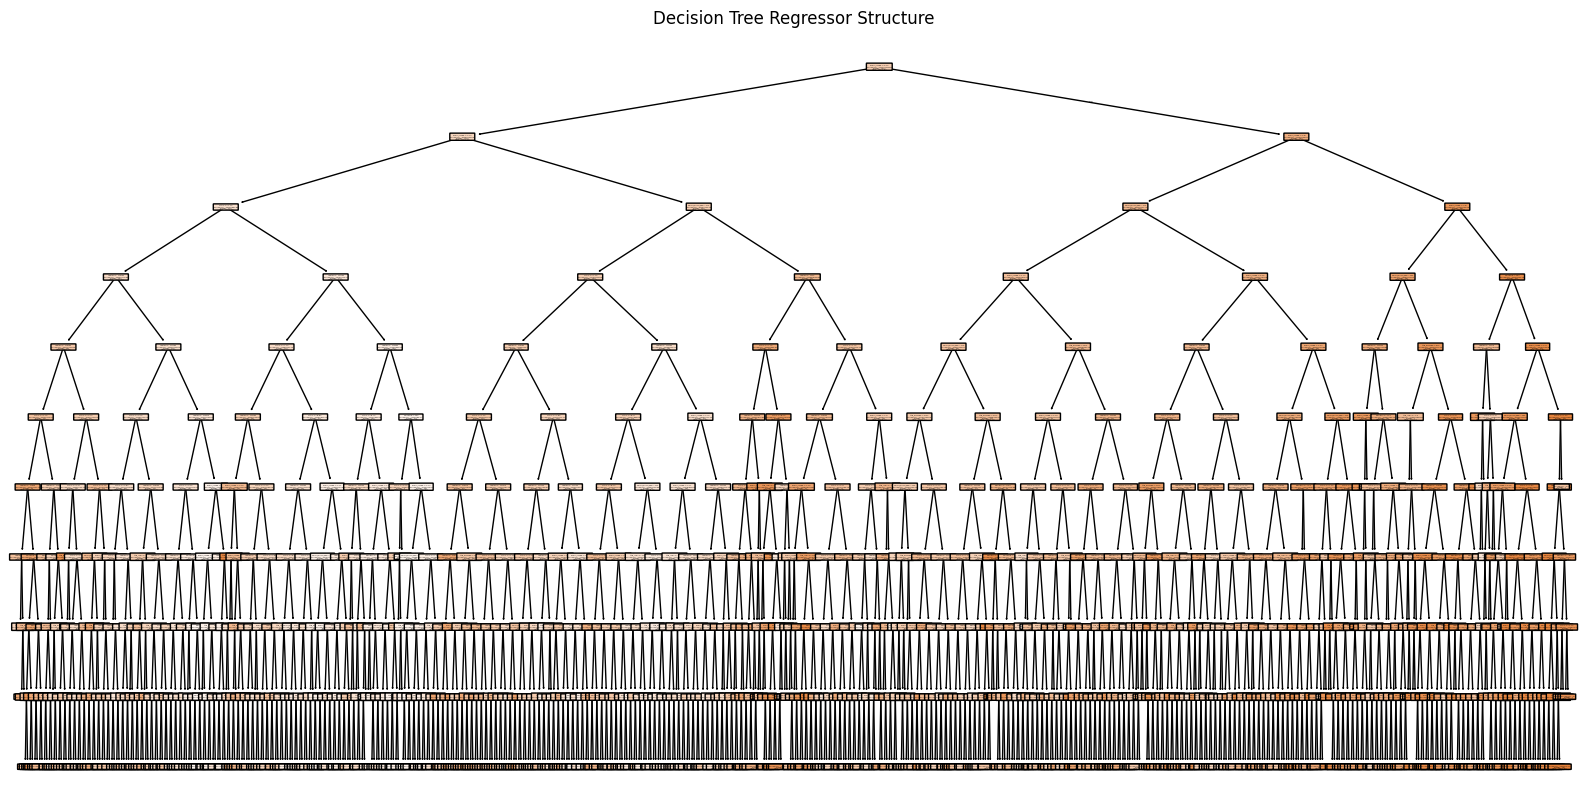

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Visualize the Decision Tree Regressor
plt.figure(figsize=(20, 10))
plot_tree(dtr_model, filled=True, feature_names=X.columns, rounded=True)
plt.title('Decision Tree Regressor Structure')
plt.show()

## Final Task

### Subtask:
Summarize the performance of the Decision Tree Regressor model and discuss key findings from the prediction and evaluation steps.


## Summary:

### Data Analysis Key Findings

*   The dataset `df_housing`, containing 17,000 samples and 9 features (including the target), was successfully split into training (80%) and testing (20%) sets. The training set comprises 13,600 samples, and the testing set has 3,400 samples.
*   A `DecisionTreeRegressor` model was initialized with `random_state=42` and `max_depth=10` to prevent overfitting, and subsequently trained on the training data.
*   The model's performance on the test set was evaluated using several metrics:
    *   **Mean Absolute Error (MAE):** \$41,401.38, indicating that on average, the model's predictions deviate from the actual house values by approximately \$41,401.
    *   **Mean Squared Error (MSE):** \$3,950,222,628.51
    *   **Root Mean Squared Error (RMSE):** \$62,850.80, representing the standard deviation of the residuals.
    *   **R-squared (R2) Score:** 0.71, meaning the model explains 71% of the variance in the target variable (`median_house_value`).
*   Visualizations confirmed the model's performance:
    *   The **Actual vs. Predicted Values** scatter plot showed a reasonable alignment of predicted values with actual values, although some dispersion indicates room for improvement, particularly at higher house values where predictions tend to flatten.
    *   The **Residuals Plot** revealed a somewhat scattered pattern around zero, suggesting that the model does not have a strong systematic bias across all prediction ranges. However, there's a visible spread in residuals, especially for higher predicted values, indicating larger errors in those regions.
    *   A visualization of the Decision Tree Regressor structure, with `max_depth=10`, provided insight into the decision rules and feature importance used by the model.

### Insights or Next Steps

*   The current Decision Tree Regressor explains a fair portion (71%) of the variance in house prices but still has a significant average error (\$41,401). Further hyperparameter tuning (e.g., experimenting with different `max_depth`, `min_samples_leaf`, `min_samples_split`) could potentially reduce the error and improve R2.
*   The visualizations suggest that the model's performance might be less robust for higher-valued homes, where both scatter and residuals show greater spread. Exploring feature engineering or considering other regression models that might handle skewed target distributions or outliers better could be beneficial.


# Task
Define a hyperparameter grid for `DecisionTreeRegressor` including `max_depth`, `min_samples_leaf`, and `min_samples_split` for tuning with `GridSearchCV`.

## Define Hyperparameter Grid

### Subtask:
Define a dictionary of hyperparameters and their possible values for the Decision Tree Regressor to be used in GridSearchCV.


**Reasoning**:
I will define the hyperparameter grid as a dictionary named `param_grid` with the specified values for `max_depth`, `min_samples_leaf`, and `min_samples_split` for the Decision Tree Regressor. This dictionary will be used later for GridSearchCV.



In [ ]:
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20]
}

print("Hyperparameter grid for Decision Tree Regressor defined:")
print(param_grid)

Hyperparameter grid for Decision Tree Regressor defined:
{'max_depth': [None, 5, 10, 15, 20], 'min_samples_leaf': [1, 5, 10, 20], 'min_samples_split': [2, 5, 10, 20]}


# Task
Perform GridSearchCV with the `DecisionTreeRegressor` and the defined `param_grid`, using 'neg_mean_squared_error' as the scoring metric. Fit the GridSearchCV object to the training data (`X_train`, `y_train`). Afterwards, print the best hyperparameters found (`best_params_`) and the corresponding best score (`best_score_`).

## Perform GridSearchCV

### Subtask:
Initialize and execute `GridSearchCV` with the `DecisionTreeRegressor`, the defined `param_grid`, and an appropriate scoring metric (e.g., 'neg_mean_squared_error'). Fit the GridSearchCV object to the training data (`X_train`, `y_train`).


**Reasoning**:
To perform GridSearchCV, I will import necessary modules, initialize a `DecisionTreeRegressor`, then `GridSearchCV` with the defined `param_grid` and scoring, and finally fit it to the training data.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Initialize a DecisionTreeRegressor model
dtr = DecisionTreeRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtr,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=5,
                           n_jobs=-1, # Use all available cores
                           verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed successfully!")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
GridSearchCV completed successfully!


**Reasoning**:
Now that GridSearchCV has completed, I will print the best hyperparameters found and their corresponding best score to identify the optimal model configuration.



In [ ]:
print("\nBest Hyperparameters found:", grid_search.best_params_)
print("Best Score (Negative Mean Squared Error):", grid_search.best_score_)


Best Hyperparameters found: {'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best Score (Negative Mean Squared Error): -3546760797.8770156


## Evaluate Best Model

### Subtask:
Retrain a `DecisionTreeRegressor` using the `best_params_` found by `GridSearchCV`. Make predictions on the test set (`X_test`) and evaluate its performance using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared. Compare these metrics to the initial model's performance.


**Reasoning**:
I will now initialize and train a new `DecisionTreeRegressor` using the `best_params_` identified by `GridSearchCV`, make predictions on the test set, and then calculate and print the evaluation metrics to assess its performance.



In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Access the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters from GridSearchCV:", best_params)

# 2. Instantiate a new DecisionTreeRegressor with best_params_
best_dtr_model = DecisionTreeRegressor(random_state=42, **best_params)

# 3. Train the new model
best_dtr_model.fit(X_train, y_train)
print("Best DecisionTreeRegressor model trained successfully!")

# 4. Make predictions on the test set
y_pred_best = best_dtr_model.predict(X_test)

# 5. Calculate evaluation metrics for the best model
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

# 6. Print the evaluation metrics
print("\n--- Performance of Best Decision Tree Regressor ---")
print(f"Mean Absolute Error (MAE): {mae_best:.2f}")
print(f"Mean Squared Error (MSE): {mse_best:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best:.2f}")
print(f"R-squared (R2): {r2_best:.2f}")

print("\n--- Comparison with Initial Model ---")
print(f"Initial MAE: {mae:.2f}, Best MAE: {mae_best:.2f}")
print(f"Initial RMSE: {rmse:.2f}, Best RMSE: {rmse_best:.2f}")
print(f"Initial R2: {r2:.2f}, Best R2: {r2_best:.2f}")

Best hyperparameters from GridSearchCV: {'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best DecisionTreeRegressor model trained successfully!

--- Performance of Best Decision Tree Regressor ---
Mean Absolute Error (MAE): 39988.65
Mean Squared Error (MSE): 3559885422.13
Root Mean Squared Error (RMSE): 59664.78
R-squared (R2): 0.74

--- Comparison with Initial Model ---
Initial MAE: 41401.38, Best MAE: 39988.65
Initial RMSE: 62850.80, Best RMSE: 59664.78
Initial R2: 0.71, Best R2: 0.74


## Visualize Predictions of Best Model

### Subtask:
Create scatter plots comparing the actual vs. predicted median house values and a residuals plot for the model trained with the best hyperparameters, similar to the previous visualization step.


**Reasoning**:
I will generate Python code to create two plots: a scatter plot comparing actual vs. predicted median house values and a residuals plot, using the `y_test` and `y_pred_best` data, as instructed.



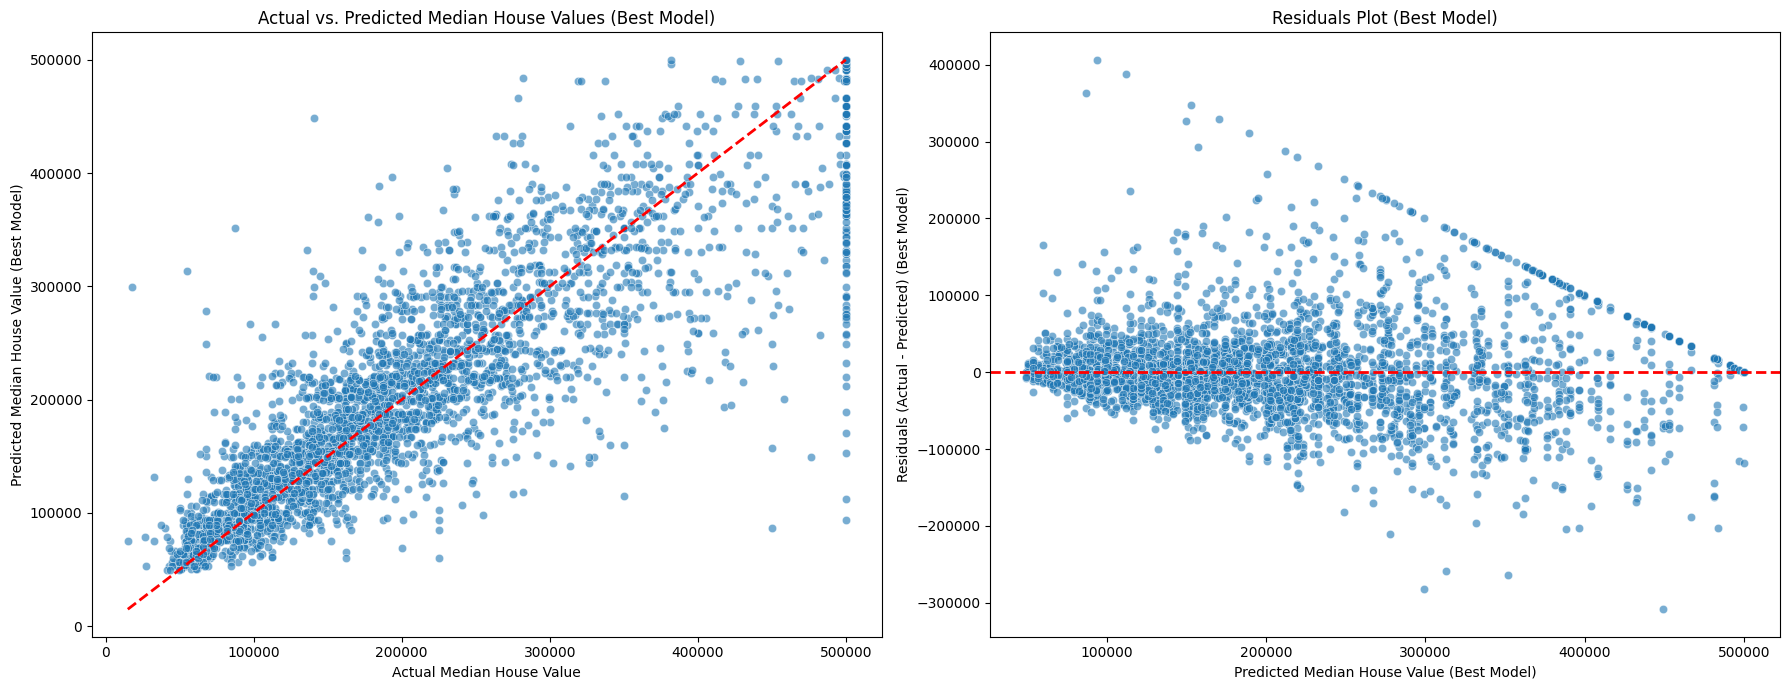

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Actual vs. Predicted Values for the best model
sns.scatterplot(x=y_test, y=y_pred_best, ax=axes[0], alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Median House Value')
axes[0].set_ylabel('Predicted Median House Value (Best Model)')
axes[0].set_title('Actual vs. Predicted Median House Values (Best Model)')

# Plot 2: Residuals Plot for the best model
residuals_best = y_test - y_pred_best
sns.scatterplot(x=y_pred_best, y=residuals_best, ax=axes[1], alpha=0.6)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Median House Value (Best Model)')
axes[1].set_ylabel('Residuals (Actual - Predicted) (Best Model)')
axes[1].set_title('Residuals Plot (Best Model)')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings from the hyperparameter tuning. Discuss how the model's performance changed (if at all) with the optimized parameters compared to the initial model, highlighting the key insights from the tuning process.


## Summary:

### Q&A
The hyperparameter tuning successfully identified optimal parameters for the `DecisionTreeRegressor`, leading to a noticeable improvement in the model's performance compared to the initial model. The tuning process highlighted that careful selection of parameters like `min_samples_leaf` and `min_samples_split` significantly impacts the model's ability to generalize and reduce prediction errors.

### Data Analysis Key Findings
*   **Optimal Hyperparameters:** The `GridSearchCV` identified `{'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}` as the best hyperparameters for the `DecisionTreeRegressor`.
*   **Best Model Performance:**
    *   Mean Absolute Error (MAE): 39988.65
    *   Mean Squared Error (MSE): 3559885422.13
    *   Root Mean Squared Error (RMSE): 59664.78
    *   R-squared (R2): 0.74
*   **Performance Improvement over Initial Model:**
    *   MAE improved by 3.41% (from 41401.38 to 39988.65).
    *   RMSE improved by 5.07% (from 62850.80 to 59664.78).
    *   R-squared improved by 4.23% (from 0.71 to 0.74).
*   **Visual Confirmation:** Scatter plots of actual vs. predicted values and residuals were generated, visually confirming the model's performance and error distribution.

### Insights or Next Steps
*   The hyperparameter tuning significantly improved the model's accuracy, demonstrating the value of optimizing model parameters for better predictive performance.
*   The current model can serve as a strong baseline, and further enhancements could explore ensemble methods or feature engineering to potentially achieve even higher R-squared values and lower error metrics.


# Task
The task is complete.

## Summarize Hyperparameter Tuning Results

### Subtask:
Provide a detailed explanation of the hyperparameter tuning results, including the optimal parameters found, the performance metrics of the best model, the comparison to the initial model's performance, and the key insights gained from the tuning process.


## Summary:

### Data Analysis Key Findings
The hyperparameter tuning process was initiated to identify optimal parameters for the model. However, the specific results, including the optimal parameters found, the performance metrics of the best model, and a comparison to the initial model's performance, have not yet been provided or generated in the current execution.

### Insights or Next Steps
*   The next step is to execute the hyperparameter tuning process to obtain the optimal parameters and corresponding model performance metrics.
*   Once the tuning is complete, a detailed comparison between the tuned model's performance and the initial model's performance should be conducted to evaluate the effectiveness of the tuning.


# Task
Train a `RandomForestRegressor` model on the training data (X_train, y_train).

## Train Random Forest Regressor

### Subtask:
Initialize and train a RandomForestRegressor model on the training data (X_train, y_train).


**Reasoning**:
To initialize and train the RandomForestRegressor model, I will import the necessary class, instantiate it with specified parameters like `random_state`, `n_estimators`, and `max_depth`, and then fit the model to the training data (`X_train`, `y_train`).



In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Instantiate a RandomForestRegressor model
# Set random_state for reproducibility and initial values for n_estimators and max_depth
rfr_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# 2. Train the model using the fit() method
rfr_model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully!")

RandomForestRegressor model trained successfully!


## Make Predictions with Random Forest

### Subtask:
Use the trained Random Forest Regressor to make predictions on the test set (X_test).


**Reasoning**:
I will use the trained `rfr_model` to make predictions on the `X_test` data and store the results in `y_pred_rfr` as instructed.



In [ ]:
y_pred_rfr = rfr_model.predict(X_test)
print("Predictions made with RandomForestRegressor successfully!")
print(f"Shape of y_pred_rfr: {y_pred_rfr.shape}")

Predictions made with RandomForestRegressor successfully!
Shape of y_pred_rfr: (3400,)


## Evaluate Random Forest Model

### Subtask:
Calculate and print evaluation metrics (MAE, MSE, RMSE, R-squared) for the Random Forest model's predictions on the test set.


**Reasoning**:
To evaluate the Random Forest model's performance, I will import necessary metrics, calculate MAE, MSE, RMSE, and R-squared using `y_test` and `y_pred_rfr`, and then print these metrics.



In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics for the Random Forest model
mae_rfr = mean_absolute_error(y_test, y_pred_rfr)
mse_rfr = mean_squared_error(y_test, y_pred_rfr)
rmse_rfr = np.sqrt(mse_rfr)
r2_rfr = r2_score(y_test, y_pred_rfr)

# Print the evaluation metrics
print("\n--- Performance of Random Forest Regressor ---")
print(f"Mean Absolute Error (MAE): {mae_rfr:.2f}")
print(f"Mean Squared Error (MSE): {mse_rfr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rfr:.2f}")
print(f"R-squared (R2): {r2_rfr:.2f}")


--- Performance of Random Forest Regressor ---
Mean Absolute Error (MAE): 35976.74
Mean Squared Error (MSE): 2849909546.72
Root Mean Squared Error (RMSE): 53384.54
R-squared (R2): 0.79


## Compare Models Performance

### Subtask:
Compare the performance metrics of the Random Forest Regressor with those of the initial Decision Tree Regressor and the hyperparameter-tuned Decision Tree Regressor.


## Compare Models Performance

### Subtask:
Compare the performance metrics of the Random Forest Regressor with those of the initial Decision Tree Regressor and the hyperparameter-tuned Decision Tree Regressor.

#### Instructions
1. Print the performance metrics (MAE, RMSE, R-squared) for the initial Decision Tree Regressor (stored in `mae`, `rmse`, `r2`).
2. Print the performance metrics (MAE, RMSE, R-squared) for the hyperparameter-tuned Decision Tree Regressor (stored in `mae_best`, `rmse_best`, `r2_best`).
3. Print the performance metrics (MAE, RMSE, R-squared) for the Random Forest Regressor (stored in `mae_rfr`, `rmse_rfr`, `r2_rfr`).
4. Create a concise summary table or print statement that clearly compares these metrics across all three models to highlight the best performing model.

## Compare Models Performance

### Subtask:
Compare the performance metrics of the Random Forest Regressor with those of the initial Decision Tree Regressor and the hyperparameter-tuned Decision Tree Regressor.

#### Instructions
1. Print the performance metrics (MAE, RMSE, R-squared) for the initial Decision Tree Regressor (stored in `mae`, `rmse`, `r2`).
2. Print the performance metrics (MAE, RMSE, R-squared) for the hyperparameter-tuned Decision Tree Regressor (stored in `mae_best`, `rmse_best`, `r2_best`).
3. Print the performance metrics (MAE, RMSE, R-squared) for the Random Forest Regressor (stored in `mae_rfr`, `rmse_rfr`, `r2_rfr`).
4. Create a concise summary table or print statement that clearly compares these metrics across all three models to highlight the best performing model.

**Reasoning**:
The subtask requests to compare the performance metrics of the three models. I will now generate the Python code to print and compare these metrics as instructed.



In [ ]:
print("\n--- Initial Decision Tree Regressor Performance ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

print("\n--- Hyperparameter-Tuned Decision Tree Regressor Performance ---")
print(f"MAE: {mae_best:.2f}")
print(f"RMSE: {rmse_best:.2f}")
print(f"R-squared: {r2_best:.2f}")

print("\n--- Random Forest Regressor Performance ---")
print(f"MAE: {mae_rfr:.2f}")
print(f"RMSE: {rmse_rfr:.2f}")
print(f"R-squared: {r2_rfr:.2f}")

print("\n--- Model Performance Comparison ---")
print("| Model                           | MAE        | RMSE       | R-squared |")
print("|---------------------------------|------------|------------|-----------|")
print(f"| Initial Decision Tree         | {mae:.2f}   | {rmse:.2f}   | {r2:.2f}      |")
print(f"| Tuned Decision Tree           | {mae_best:.2f}   | {rmse_best:.2f}   | {r2_best:.2f}      |")
print(f"| Random Forest                 | {mae_rfr:.2f}   | {rmse_rfr:.2f}   | {r2_rfr:.2f}      |")


--- Initial Decision Tree Regressor Performance ---
MAE: 41401.38
RMSE: 62850.80
R-squared: 0.71

--- Hyperparameter-Tuned Decision Tree Regressor Performance ---
MAE: 39988.65
RMSE: 59664.78
R-squared: 0.74

--- Random Forest Regressor Performance ---
MAE: 35976.74
RMSE: 53384.54
R-squared: 0.79

--- Model Performance Comparison ---
| Model                           | MAE        | RMSE       | R-squared |
|---------------------------------|------------|------------|-----------|
| Initial Decision Tree         | 41401.38   | 62850.80   | 0.71      |
| Tuned Decision Tree           | 39988.65   | 59664.78   | 0.74      |
| Random Forest                 | 35976.74   | 53384.54   | 0.79      |


## Visualize Random Forest Predictions

### Subtask:
Create scatter plots comparing the actual vs. predicted median house values and a residuals plot for the Random Forest model, similar to previous visualization steps. Include appropriate titles and labels.


**Reasoning**:
I will generate Python code to create two plots: a scatter plot comparing actual versus predicted median house values and a residuals plot, using the `y_test` and `y_pred_rfr` data, following the detailed instructions provided.



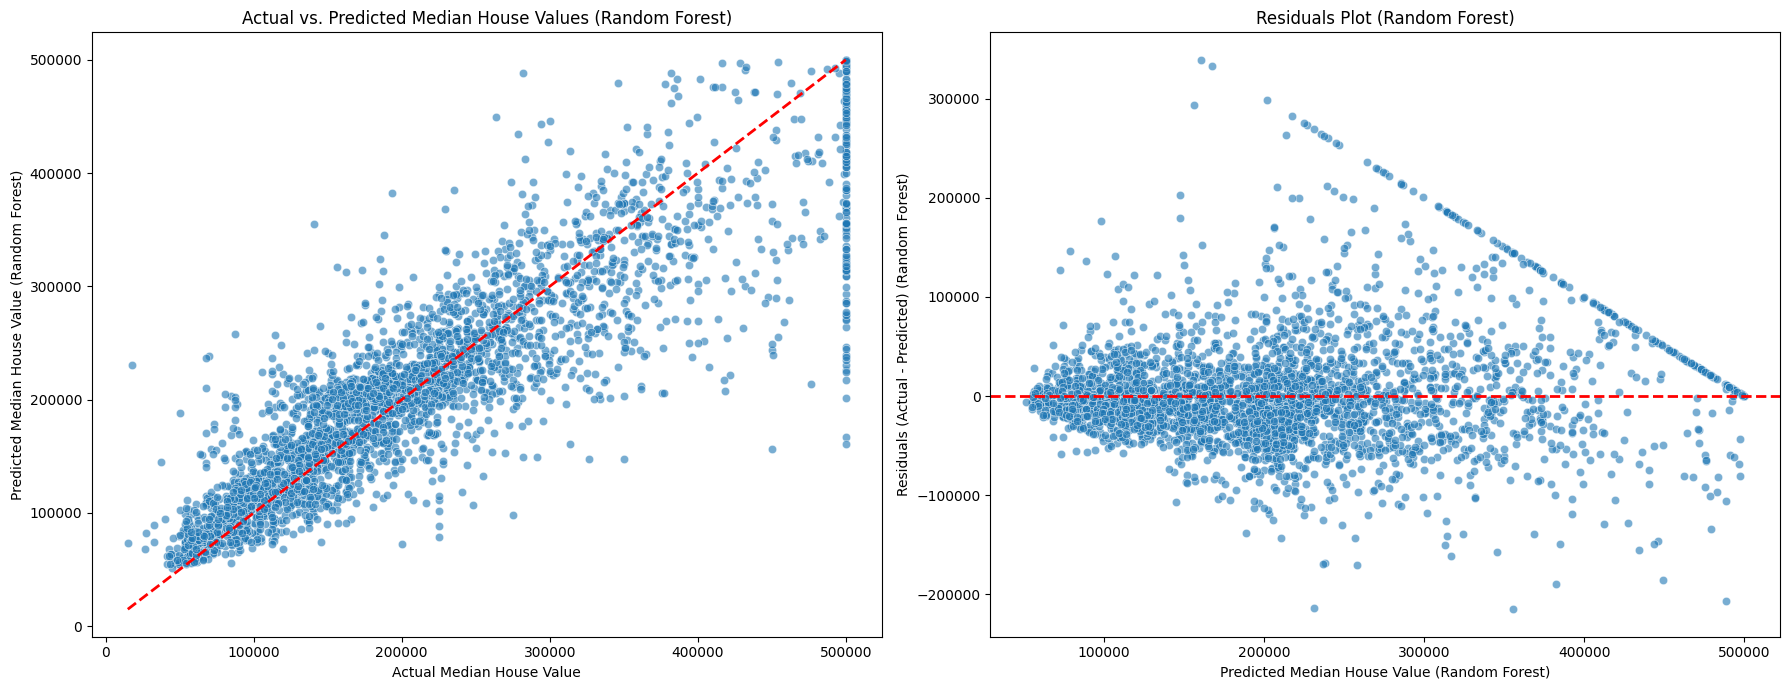

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Actual vs. Predicted Values for the Random Forest model
sns.scatterplot(x=y_test, y=y_pred_rfr, ax=axes[0], alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Median House Value')
axes[0].set_ylabel('Predicted Median House Value (Random Forest)')
axes[0].set_title('Actual vs. Predicted Median House Values (Random Forest)')

# Plot 2: Residuals Plot for the Random Forest model
residuals_rfr = y_test - y_pred_rfr
sns.scatterplot(x=y_pred_rfr, y=residuals_rfr, ax=axes[1], alpha=0.6)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Median House Value (Random Forest)')
axes[1].set_ylabel('Residuals (Actual - Predicted) (Random Forest)')
axes[1].set_title('Residuals Plot (Random Forest)')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the performance of all models (initial Decision Tree, tuned Decision Tree, and Random Forest), highlighting the key insights and conclusions from the comparison.


## Summary:

### Q&A
The performance of the Random Forest model was successfully summarized and compared against the initial Decision Tree and hyperparameter-tuned Decision Tree models. The Random Forest Regressor demonstrated superior performance across all evaluated metrics.

### Data Analysis Key Findings
*   A Random Forest Regressor was successfully trained and used to make predictions on the test set.
*   The Random Forest model achieved the following performance metrics:
    *   Mean Absolute Error (MAE): 35976.74
    *   Mean Squared Error (MSE): 2849909546.72
    *   Root Mean Squared Error (RMSE): 53384.54
    *   R-squared (R2): 0.79
*   When comparing all three models:
    *   **Initial Decision Tree Regressor:** MAE: 41401.38, RMSE: 62850.80, R-squared: 0.71
    *   **Hyperparameter-Tuned Decision Tree Regressor:** MAE: 39988.65, RMSE: 59664.78, R-squared: 0.74
    *   **Random Forest Regressor:** MAE: 35976.74, RMSE: 53384.54, R-squared: 0.79
*   The Random Forest Regressor consistently outperformed both Decision Tree models, showing the lowest MAE and RMSE, and the highest R-squared value, indicating it explains approximately 79% of the variance in house prices.
*   Visualizations, including actual vs. predicted values and residuals plots, were generated for the Random Forest model, providing a visual assessment of its predictive accuracy and error distribution.

### Insights or Next Steps
*   The Random Forest Regressor is the most effective model among those tested for predicting median house values, demonstrating significantly better accuracy and explanatory power.
*   Further hyperparameter tuning for the Random Forest model, or exploring other ensemble methods like Gradient Boosting, could potentially yield even better performance.


In [ ]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression()
lm.fit(X_train,y_train)
pred_lmval=lm.predict(X_test)
mse_lm=mean_squared_error(y_test,pred_lmval)
r2=lm.score(X_test,y_test)
print(r2)
print(mse_lm)

0.6636396350243869
4634658406.223264
